# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-06-02 16:11:04.533211: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-02 16:11:04.538071: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-02 16:11:04.619055: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-02 16:11:04.619177: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-02 16:11:04.619227: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
## INSERT YOUR CODE HERE ##
data = data.drop(columns=['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'])

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
## INSERT YOUR CODE HERE ##
data['attack'] = np.where(data['attack'] != 'normal', 'attack', data['attack'])

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
## INSERT YOUR CODE HERE ##
le = LabelEncoder()

cols = ['protocoltype', 'service', 'flag', 'attack']
for col in cols:
    data[col] = le.fit_transform(data[col])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

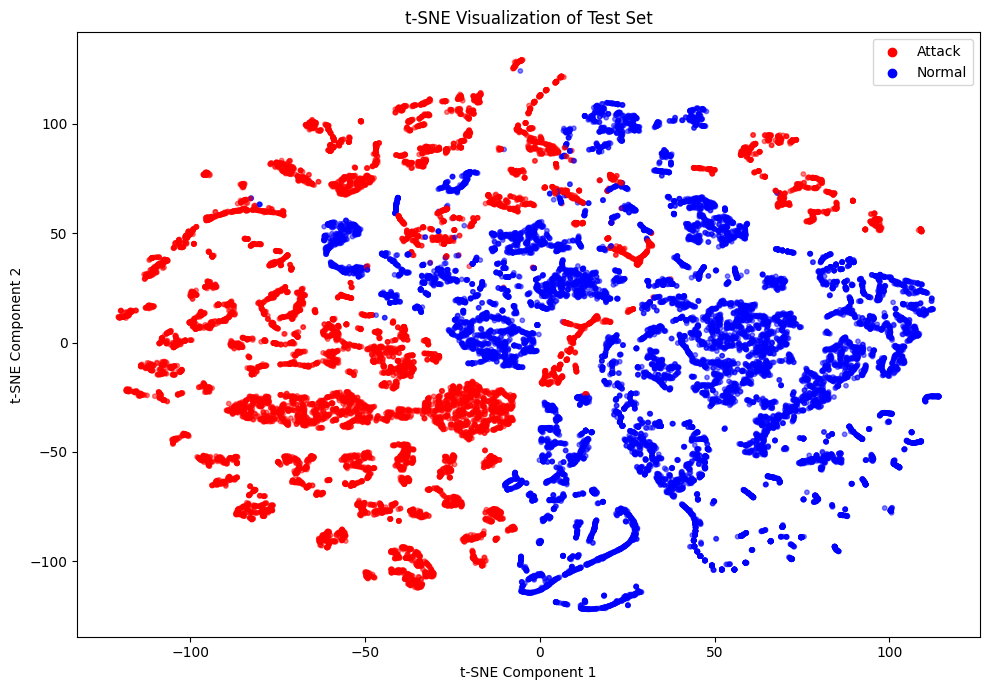

In [10]:
from sklearn.manifold import TSNE
## INSERT YOUR CODE HERE ##
#flattening y_test
y_test_flat = y_test.flatten()

tsne = TSNE(n_components=2, random_state=42)
X_test_2d = tsne.fit_transform(X_test)

# Creating color array based on y_test labels
colors = ['red' if label == 0 else 'blue' for label in y_test]

# Plotting
plt.figure(figsize=(10, 7))
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors, alpha=0.5, s=10)

# Legend
plt.scatter([], [], c='red', label='Attack')
plt.scatter([], [], c='blue', label='Normal')
plt.legend()

plt.title('t-SNE Visualization of Test Set')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

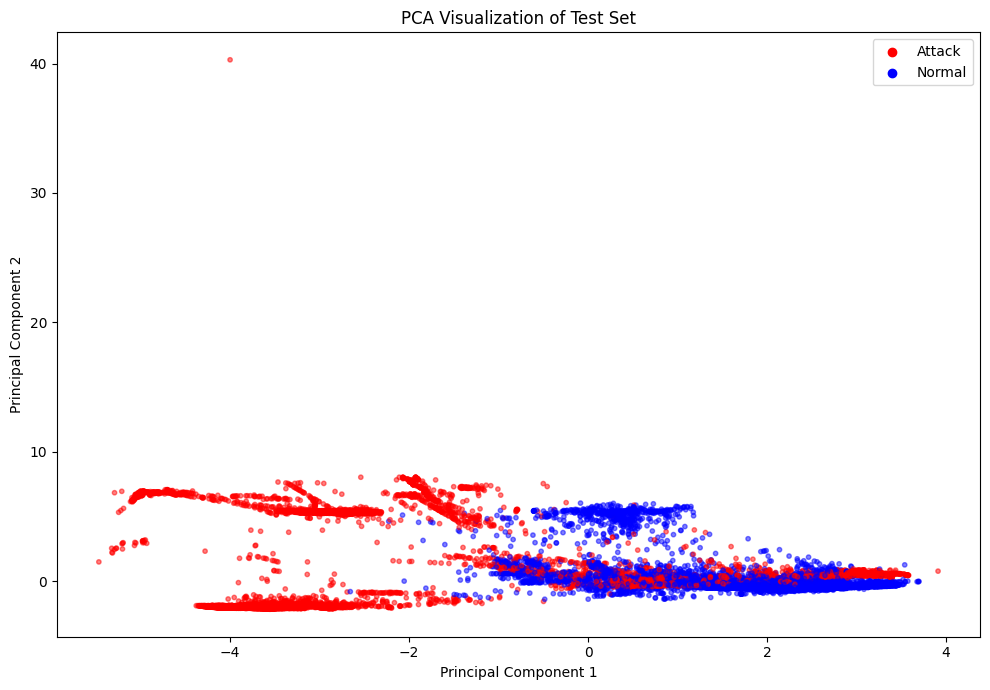

In [11]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##

# Applying PCA to reduce X_test to 2D
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

# Flattening y_test for indexing
y_test_flat = y_test.flatten()

# attack=0 → red, normal=1 → blue
colors = ['red' if label == 0 else 'blue' for label in y_test_flat]

# Plotting
plt.figure(figsize=(10, 7))
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors, alpha=0.5, s=10)

# Legend
plt.scatter([], [], c='red', label='Attack')
plt.scatter([], [], c='blue', label='Normal')
plt.legend()

plt.title('PCA Visualization of Test Set')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

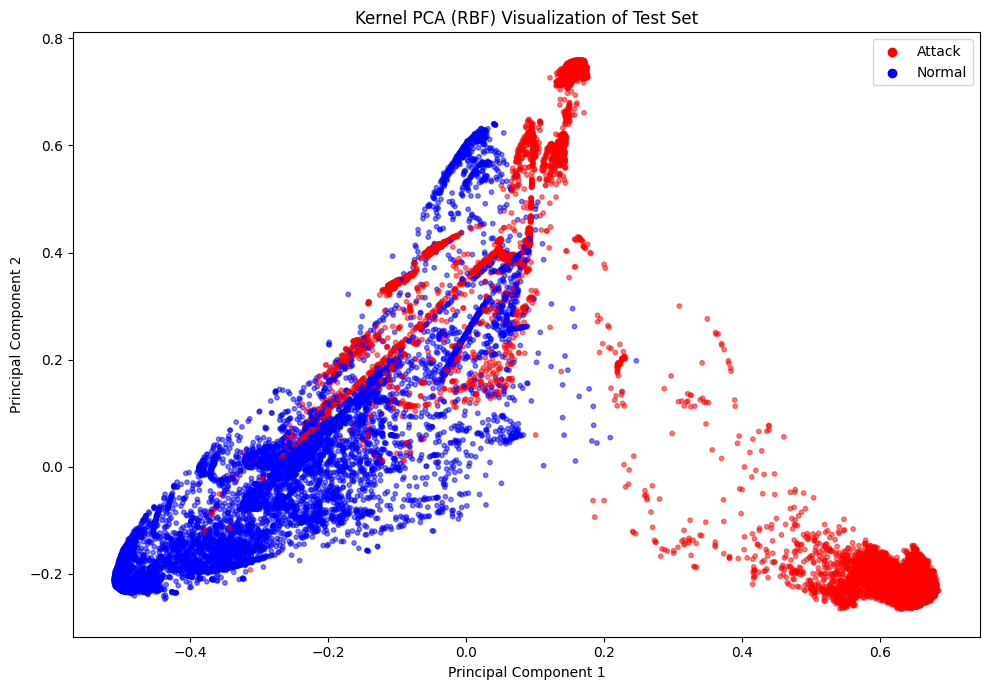

In [12]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##

# Applying Kernel PCA with RBF kernel to reduce X_test to 2D
kpca = KernelPCA(n_components=2, kernel='rbf')
X_test_2d = kpca.fit_transform(X_test)

# Flattening y_test for indexing
y_test_flat = y_test.flatten()

# attack=0 → red, normal=1 → blue
colors = ['red' if label == 0 else 'blue' for label in y_test_flat]

# Plotting
plt.figure(figsize=(10, 7))
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors, alpha=0.5, s=10)

# Legend
plt.scatter([], [], c='red', label='Attack')
plt.scatter([], [], c='blue', label='Normal')
plt.legend()

plt.title('Kernel PCA (RBF) Visualization of Test Set')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [13]:
# Define the DNN model
base_model = Sequential([
    ## INSERT YOUR CODE HERE ##
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:
## INSERT YOUR CODE HERE ##
# Compile the model
base_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Train the model
history = base_model.fit(X_train, y_train,
                         epochs=20,
                         batch_size=32,
                         validation_data=(X_test, y_test))

Epoch 1/20
3150/3150 [==============================] - 13s 4ms/step - loss: 0.0225 - accuracy: 0.9933 - val_loss: 0.0125 - val_accuracy: 0.9956
Epoch 2/20
3150/3150 [==============================] - 11s 4ms/step - loss: 0.0095 - accuracy: 0.9968 - val_loss: 0.0075 - val_accuracy: 0.9967
Epoch 3/20
3150/3150 [==============================] - 20s 6ms/step - loss: 0.0067 - accuracy: 0.9975 - val_loss: 0.0052 - val_accuracy: 0.9984
Epoch 4/20
3150/3150 [==============================] - 17s 5ms/step - loss: 0.0059 - accuracy: 0.9979 - val_loss: 0.0073 - val_accuracy: 0.9971
Epoch 5/20
3150/3150 [==============================] - 14s 4ms/step - loss: 0.0052 - accuracy: 0.9981 - val_loss: 0.0052 - val_accuracy: 0.9985
Epoch 6/20
3150/3150 [==============================] - 10s 3ms/step - loss: 0.0041 - accuracy: 0.9985 - val_loss: 0.0050 - val_accuracy: 0.9982
Epoch 7/20
3150/3150 [==============================] - 14s 4ms/step - loss: 0.0043 - accuracy: 0.9984 - val_loss: 0.0054 - val_ac

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 2s 2ms/step
Classification Report:
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11503
      Normal       1.00      1.00      1.00     13692

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



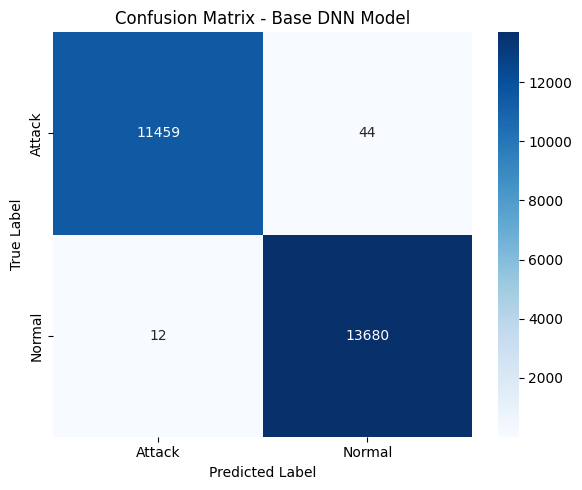

In [15]:
## INSERT YOUR CODE HERE ##

# Getting predictions
y_pred = base_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Flattening y_test
y_test_flat = y_test.flatten()

# Classification Report
print("Classification Report:")
print(classification_report(y_test_flat, y_pred_classes, target_names=['Attack', 'Normal']))

# Confusion Matrix
cm = confusion_matrix(y_test_flat, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix - Base DNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

## INSERT YOUR CODE HERE ##
# Convert to TFLite with Dynamic Range Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)

# Enable Dynamic Range Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_quant_model = converter.convert()

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("Original model size:  ", base_model.count_params() * 4, "bytes")
print("Quantized model size: ", len(tflite_quant_model), "bytes")

INFO:tensorflow:Assets written to: /tmp/tmp9jk12ujp/assets


INFO:tensorflow:Assets written to: /tmp/tmp9jk12ujp/assets


Original model size:   61576 bytes
Quantized model size:  18928 bytes


2026-06-02 16:19:21.346546: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-02 16:19:21.347447: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-02 16:19:21.353451: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp9jk12ujp
2026-06-02 16:19:21.355373: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-02 16:19:21.355400: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp9jk12ujp
2026-06-02 16:19:21.360823: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-02 16:19:21.362387: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-02 16:19:21.425102: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp9jk12ujp
2026-06

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 221.01 KB
Quantized model size: 18.48 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Classification Report (Dynamic Range Quantized Model):
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11503
      Normal       1.00      1.00      1.00     13692

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



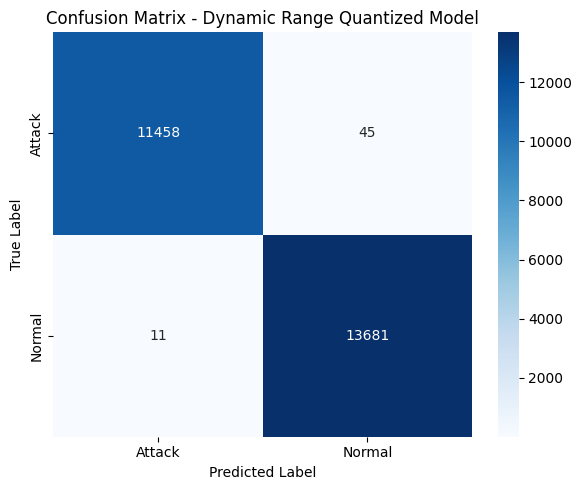

In [19]:
## INSERT YOUR CODE HERE ##
# Initialize the TFLite interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run inference on the full test set
y_pred_quant = []

for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_quant.append(np.argmax(output))

y_pred_quant = np.array(y_pred_quant)

# Flatten y_test
y_test_flat = y_test.flatten()

# Classification Report
print("Classification Report (Dynamic Range Quantized Model):")
print(classification_report(y_test_flat, y_pred_quant, target_names=['Attack', 'Normal']))

# Confusion Matrix
cm_quant = confusion_matrix(y_test_flat, y_pred_quant)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_quant, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix - Dynamic Range Quantized Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Converting tflite_model to C and create the header file

In [20]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [21]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [22]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.00770704772403217, -0.0039137337729048495, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.3681102129968653, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    -1.5034293926164772, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.38310818187794965, -0.11142568757652836, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.11024922

In [23]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 1, 1, 0, 1
};



In [24]:
import numpy as np
import tensorflow as tf

# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# Representative dataset generator (required for full int8 quantization)
def representative_dataset():
    for i in range(100):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

# Convert with Full Integer Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Force full int8 quantization for both inputs and outputs
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert the model
tflite_quant_model = converter.convert()

# Save the quantized model
with open('full_int8_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("Original model size:  ", base_model.count_params() * 4, "bytes")
print("Quantized model size: ", len(tflite_quant_model), "bytes")

INFO:tensorflow:Assets written to: /tmp/tmpwfqso6gl/assets


INFO:tensorflow:Assets written to: /tmp/tmpwfqso6gl/assets
2026-06-02 17:00:12.609266: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-02 17:00:12.609808: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Original model size:   61576 bytes
Quantized model size:  19088 bytes


2026-06-02 17:00:12.610872: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpwfqso6gl
2026-06-02 17:00:12.612242: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-02 17:00:12.612291: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpwfqso6gl
2026-06-02 17:00:12.619098: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-02 17:00:12.669919: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpwfqso6gl
2026-06-02 17:00:12.678144: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 67253 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [27]:
import c_writer

# Convert full int8 model to hex array
hex_array = [format(val, '#04x') for val in tflite_quant_model]

# Create C array string
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")

# Wrap in header guard
header_str = c_writer.create_header(c_model, "network_model")

# Write to header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

print("network_model.h generated successfully!")
print(f"Model size: {len(tflite_quant_model)} bytes")

network_model.h generated successfully!
Model size: 19088 bytes


In [28]:
# If you need to reload from file
with open('full_int8_model.tflite', 'rb') as f:
    tflite_quant_model = f.read()

hex_array = [format(val, '#04x') for val in tflite_quant_model]
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
header_str = c_writer.create_header(c_model, "network_model")

with open('network_model.h', 'w') as file:
    file.write(header_str)

print("network_model.h generated successfully!")

network_model.h generated successfully!


In [29]:
# Extract samples 5-14 (excluding first 5)
Xtest_new = X_test[5:15, :]
ytest_new = y_test[5:15].flatten()

print("X_test samples 5-14:")
print(c_writer.create_array(Xtest_new, "float", "X_test"))

print("y_test labels 5-14:")
print(c_writer.create_array(ytest_new, "uint8_t", "y_test"))

X_test samples 5-14:
const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.6867852074966913, 
    0.7511112872365361, -0.005662861926380684, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.708312489286426, -0.35434285002584825, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.02063672680271294, 3.366063639474973, -0.37455970440553465, 
    -1.4227889618580227, 0.0663671387025361, 0.6877379851830725, 
    -0.06855302025511306, 2.205922901798524, -0.11142568757652836, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.652822878